# $O(n \log n)$ distance-weighted bipartite matching on a real road network with pyrosm and GeoPandas

In this notebook we demonstrate the usage of an efficient $O(n \log n)$ algorithm to compute the optimal distance-weighted matching between two sets of points distributed over a [metric graph](https://en.wikipedia.org/wiki/Quantum_graph#Metric_graphs). Specifically, we use the driving network of Cambridge, MA. Note, the roadmap includes both one-way roads and those with bidirectional travel simultaneously, which our algorithms support.

## Introducing Cambridge, MA

We begin by loading data using the tutorial material on the PYROSM website.

Number of roads: 9914


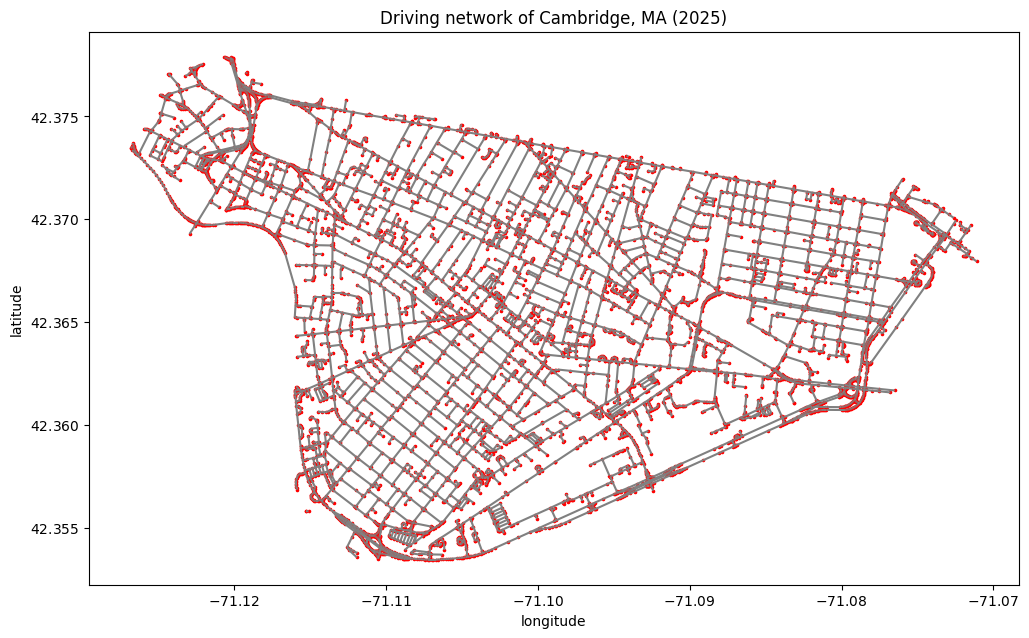

In [1]:
"""
Starting with the online tutorial.
https://pyrosm.readthedocs.io/en/stable/basics.html#

"""
from pyrosm import OSM
import matplotlib as mpl
mpl.rcParams["axes.formatter.use_mathtext"] = True

import matplotlib.pyplot as plt

# Data prepared using UI at https://extract.bbbike.org/
# https://pyrosm.readthedocs.io/en/stable/basics.html#protobuf-file-what-is-it-and-how-to-get-one
path = "data/cam.osm.pbf"
osm = OSM(path)

# Read nodes and edges of the 'driving' network
nodes, edges = osm.get_network(nodes=True, network_type="driving")

# Plot nodes and edges on a map
ax = edges.plot(figsize=(12, 8), color="gray")
nodes.plot(color="red", markersize=2.5, ax=ax)
plt.title("Driving network of Cambridge, MA (2025)")
plt.xlabel("longitude")
plt.ylabel("latitude");

print(f"Number of roads: {len(edges)}")

For higher-fidelity distance calculations in meters, we will use a more appropriate map projection for the region of interest (the Boston area).

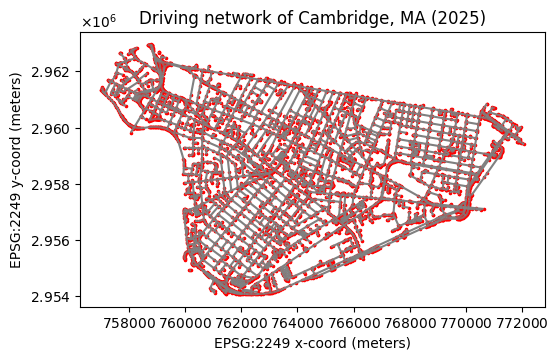

In [2]:
# Project to Boston area for metric (near-Euclidean) distance
nodes, edges = map(lambda gdf: gdf.to_crs("EPSG:2249"), (nodes, edges))

# Plot nodes and edges on a map
ax = edges.plot(figsize=(6,6), color="gray")
nodes.plot(color="red", markersize=2.5, ax=ax)
plt.title("Driving network of Cambridge, MA (2025)")
plt.xlabel("EPSG:2249 x-coord (meters)")
plt.ylabel("EPSG:2249 y-coord (meters)");

## Thesis statement

The gray segments show the space occupied by roads in Cambridge, and the red dots show the locations of interchange. While there are many red dots, of course they do not cover the whole continuum of the road network.

Typically, if you want to know the shortest path between two points on the network, the standard way is to find the nearest vertices to the query points, and use the graph shortest path distance as a proxy.
Indeed, the PYROSM docs have a tutorial for this method:
https://pyrosm.readthedocs.io/en/stable/graphs.html#calculate-shortest-paths

Our library provides support if you would like higher precision than that. To our library a point is the tuple $(r, x)$ of a road $r$ and a coordinate $x$ describing the distance one would travel along that road from its origin to reach the point.

In [3]:
# Build a representation of the distance metric
from setiptah.roadgeometry.graphs import RoadNetwork

rn = RoadNetwork()

for _, row in nodes.iterrows():
    rn.add_node(row.id)
    pt = row.geometry
    # node_location[row.id] = (pt.x, pt.y)

for r, row in edges.iterrows():
    rn.add_edge(r, row.u, row.v, row.geometry.length, oneway=row.oneway == "yes")

from collections import Counter
print("One way roads?")
Counter(rn.is_oneway(road) for road in rn.edges())

One way roads?


Counter({False: 5092, True: 4822})

## Matching / Assignment

We will demonstrate our shortest path capabilities within the context of another major contribution of the library, an algorithm to provide a minimum matching between supply and demand in the sense of least total shortest path distance on a network.

To demonstrate, suppose we have $n$ units of some commodity / supply (...probably pizza) loaded in trucks at various locations in the network. They need to be delivered to $n$ consumers / demand (grad students) at other locations.

### Naive Matching

We'll start by demonstrating how to compute the "carbon footprint" of a matching.

First, let's sample some points..

Sampling on the road network


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 17.77it/s]


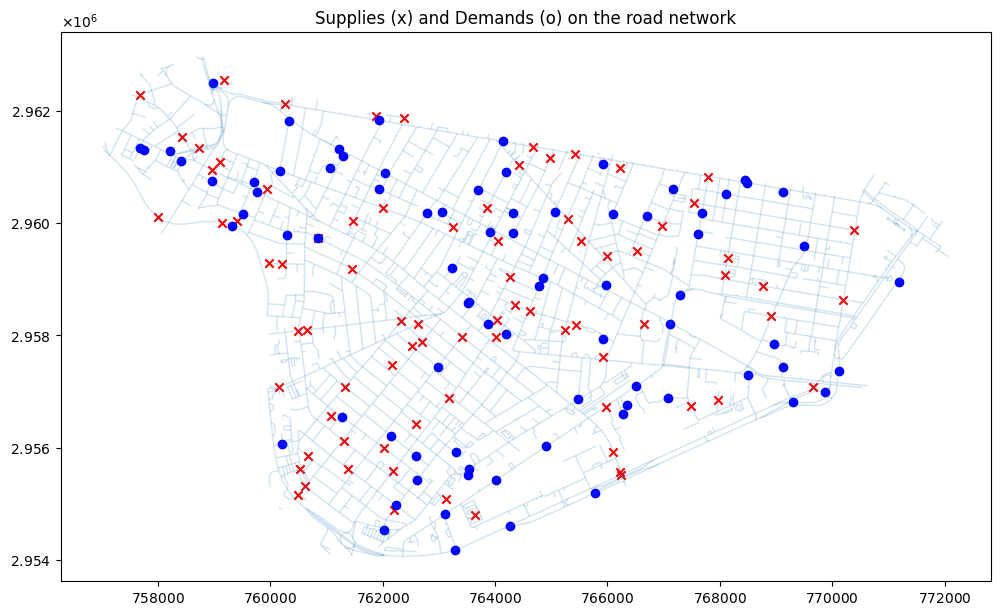

In [4]:
# Sample some supply and demand on the network continuum.
from setiptah.roadgeometry.formats import to_networkx
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
from setiptah.roadgeometry.geopandas import points_to_gdf

roadmap = to_networkx(rn)

import setiptah.roadgeometry.probability as roadprob

uniform = roadprob.UniformDist(roadmap)

print("Sampling on the road network")
from setiptah.roadgeometry.dijkstra import RoadnetMetric
metric = RoadnetMetric(rn)

supply, demand = [], []
for _ in tqdm(range(80)):
    while True:
        s, t = [tuple(uniform.sample()) for _ in range(2)]
        if metric.distance(s, t) < np.inf:
            supply.append(s)
            demand.append(t)
            break

# Show supply and demand on the map
supply_gdf, demand_gdf = points_to_gdf(supply, edges), points_to_gdf(demand, edges)

ax = edges.plot(linewidth=1, alpha=.2, figsize=(12, 8))
supply_gdf.plot(color="red", marker="x", ax=ax)
demand_gdf.plot(color="blue", marker="o", ax=ax)
plt.title("Supplies (x) and Demands (o) on the road network");

Now suppose we naively match the first supply to first demand, the second to the second, and so on.
Let's calculate the total shortest path distance.

In [5]:
# Prepare some memory for shortest path caching
from setiptah.roadgeometry.dijkstra import RoadnetMetric
from setiptah.roadgeometry.matching.geopandas import create_path_network_with_surplus

pathnet, segments_gdf = create_path_network_with_surplus(supply, demand, rn, edges)
path_metric = RoadnetMetric(pathnet)

In [6]:
# Compute the "carbon footprint" of the matching.
# For each segment in the network, add up the number of shortest paths traversing the segment.
from setiptah.roadgeometry.dijkstra import RoadnetMetric, PointNode

r = range(len(supply))
naive_matching = list(zip(r, r))

print("Calculating link weights")

def get_link_weights(matching):
    weights = pd.Series(0, index=segments_gdf.index)

    for i, j in tqdm(matching):
        s, t = supply[i], demand[j]
        path = path_metric.graph_shortest_path(PointNode(s), PointNode(t))
        weights.loc[path[1::2]] += 1

    return weights

weights_naive = get_link_weights(naive_matching)

Calculating link weights


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 23.46it/s]


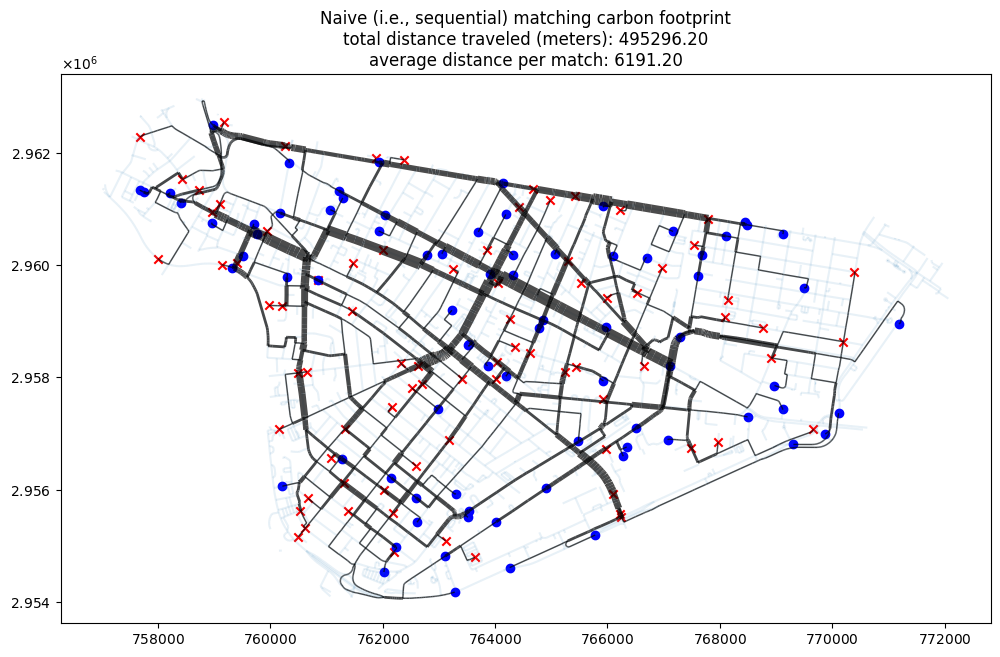

In [7]:
# Plot carbon footprint
def plot_w_linewidth_fixed(gdf, *args, linewidth, ax=None, **kwargs):
    for w in set(linewidth):
        ax = gdf[linewidth == w].plot(*args, linewidth=w, ax=ax, **kwargs)
    return ax

ax = edges.plot(alpha=.1, figsize=(12, 8))
ax = plot_w_linewidth_fixed(segments_gdf, linewidth=weights_naive, alpha=.7, colors="black", ax=ax)
ax = supply_gdf.plot(color="red", marker="x", ax=ax)
ax = demand_gdf.plot(color="blue", marker="o", ax=ax);

# Total matching distance according to segment occupancy, or "carbon trail"
segment_occupancy = weights_naive  # alias
total_weight = (segment_occupancy * segments_gdf.geometry.length).sum()


plt.title("\n".join([
    "Naive (i.e., sequential) matching carbon footprint",
    f"total distance traveled (meters): {total_weight:.02f}",
    f"average distance per match: {total_weight / len(supply):.02f}",
]));

An interesting feature of this plot is that it predicts where the heavy congestion areas are likely to be.

Let's just make sure the math checks out:

In [8]:
# Matching cost according to the network metric..
metric_distance = sum(
    metric.distance(supply[i], demand[j])
    for i, j in naive_matching
)

# ..and according to the _path_ metric
path_metric_distance = sum(
    path_metric.graph_shortest_path_length(PointNode(supply[i]), PointNode(demand[j]))
    for i, j in naive_matching
)

distances = np.array([
    total_weight,  # computed previously from segment occupancies
    metric_distance,
    path_metric_distance,
])

median_total_distance, max_error = np.median(distances), distances.max() - distances.min()
assert max_error < 1e-8, max_error

### Optimal Matching

Now let's find an _optimal_ matching using the present library.

In [9]:
from setiptah.roadgeometry.matching import RoadnetMatchingProblem, MatchingResult

optimal_matching, optimal_cost = RoadnetMatchingProblem(supply, demand, rn).compute_optimal_results(MatchingResult.MATCHING, MatchingResult.COST)

In [10]:
# Calculate the carbon footprint.
weights_optimal = get_link_weights(optimal_matching)

# Check cost of shortest paths vs. cost reported by algorithm!
total_distance_optimal = (weights_optimal * segments_gdf.geometry.length).sum()

error = abs(total_distance_optimal - optimal_cost)
assert error < 1e-8, error

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 4094.85it/s]


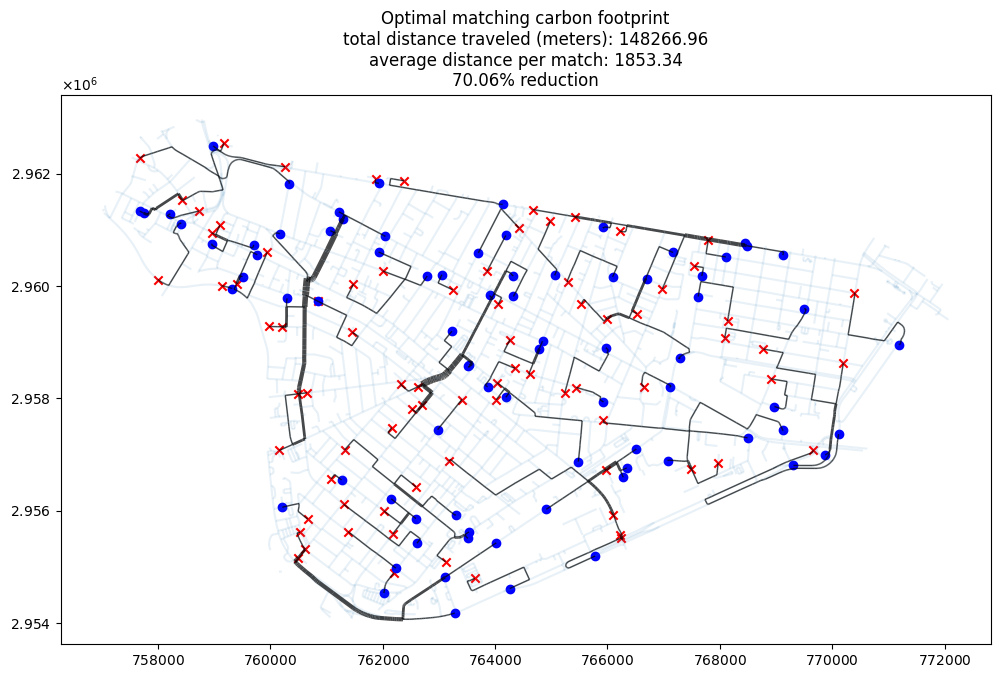

In [11]:
# Visualize optimal matching.
ax = edges.plot(alpha=.1, figsize=(12, 8))
ax = plot_w_linewidth_fixed(segments_gdf, linewidth=weights_optimal, alpha=.7, colors="black", ax=ax)
ax = supply_gdf.plot(color="red", marker="x", ax=ax)
ax = demand_gdf.plot(color="blue", marker="o", ax=ax);

reduction = (total_weight - total_distance_optimal) / total_weight
plt.title("\n".join([
    "Optimal matching carbon footprint",
    f"total distance traveled (meters): {total_distance_optimal:.02f}",
    f"average distance per match: {total_distance_optimal / len(supply):.02f}",
    f"{reduction * 100:.02f}% reduction",
]));

The total cost reduction is of course significant.
And it becomes more and more significant as the instance size increases!

## About the Algorithm

Before concluding, we'll discuss a bit about the intuition behind the optimal matching algorithm:

### Matching on a line segment

Our matching algorithm builds on the intuition behind optimal matching on the _simplest_ kind of road network -- a single line segment.

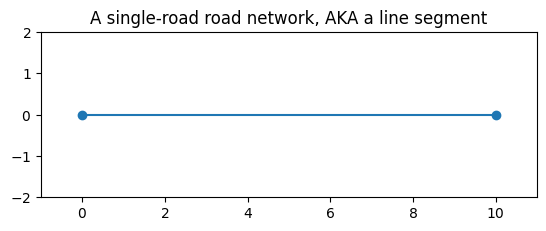

In [12]:
from shapely import Point
from setiptah.roadgeometry.geopandas import GeoFramesRoads

nodes = gpd.GeoDataFrame(
    dict(point=[Point(0, 0), Point(10, 0)]),
    geometry="point",
    crs=None,
)
topology = pd.DataFrame(
    {
        "u": [0],
        "v": [1],
    },
    index=["R"],
)
one_road = GeoFramesRoads(topology, "u", "v").straight_lines_on(nodes)

ax = one_road.edges_gdf.plot()
one_road.nodes_gdf.plot(ax=ax)
plt.axis([-1, 11, -2, 2]);
plt.title("A single-road road network, AKA a line segment");

As before, we can generate some "random" supply and demand.

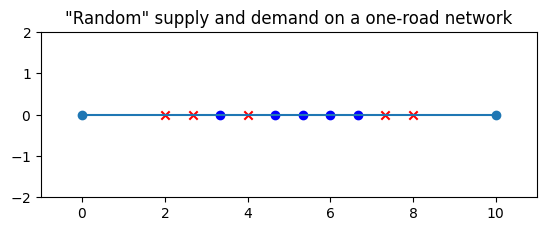

In [19]:
import numpy as np
from setiptah.roadgeometry.geopandas import points_to_gdf

seq = "ssdsddddss"
xs = np.linspace(2, one_road.length("R") - 2, len(seq))

supply = [("R", x) for t, x in zip(seq, xs) if t == "s"]
demand = [("R", x) for t, x in zip(seq, xs) if t == "d"]

supply_gdf, demand_gdf = points_to_gdf(supply, one_road.edges_gdf), points_to_gdf(demand, one_road.edges_gdf)

ax = one_road.edges_gdf.plot()
one_road.nodes_gdf.plot(ax=ax)
supply_gdf.plot(ax=ax, color="red", marker="x")
demand_gdf.plot(ax=ax, color="blue", marker="o")
plt.axis([-1, 11, -2, 2]);
plt.title('"Random" supply and demand on a one-road network');

### Sequential matching is optimal (on a segment)

It turns out that on a line segment, sequential matching is optimal: the first supply matches the first demand, the second the second, and so on.

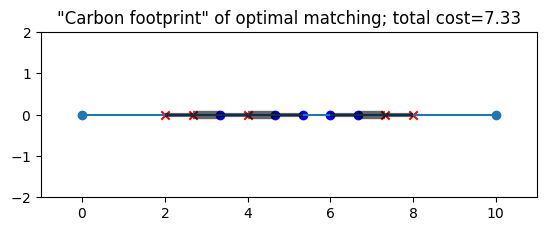

In [14]:
from setiptah.roadgeometry.matching.geopandas import create_path_network_with_surplus

pathnet, segments_gdf = create_path_network_with_surplus(supply, demand, one_road, one_road.edges_gdf)
path_metric = RoadnetMetric(pathnet)

total_distance = 0
weights = pd.Series(0, segments_gdf.index)
for s, t in zip(supply, demand):  # sequential matching!
    path = path_metric.graph_shortest_path(PointNode(s), PointNode(t))
    segments = path[1::2]
    weights[segments] += 1
    total_distance += segments_gdf.loc[segments].geometry.length.sum()

WIDTH_PER_WEIGHT = 3

ax = one_road.edges_gdf.plot()
one_road.nodes_gdf.plot(ax=ax)
segments_gdf.plot(ax=ax, alpha=.6, linewidth=weights * WIDTH_PER_WEIGHT, color="k")
supply_gdf.plot(ax=ax, color="red", marker="x")
demand_gdf.plot(ax=ax, color="blue", marker="o")

plt.axis([-1, 11, -2, 2]);
plt.title(f'"Carbon footprint" of optimal matching; total cost={total_distance:.02f}');

### Total matching cost and cumulative surplus

Given the simple form of the optimal matching on the line segment, there is a useful characterization of its distance-weighted cost:

We can see above that every interval hosts a number of shortest paths equal to the magnitude of the _cumulative surplus_ along that interval.
The cumulative surplus at a point $(r, x)$ is the difference between the number of supply on $r$ with coordinate $x' \leq x$ and the number of demand in the same range.
(It is therefore constant between points.)
With $F_r$ denoting the _cumulative surplus function_ (csf) for the road $r$ of length $|r|$,
the total cost of the optimal matching is equal to
$$\int_0^{|r|} | F_r(x) | \ {\rm d} x.$$

Critically, the csf is a function of the supply and demand only, and does not require materialization of an optimal matching. (More on that later.)

Now let's see if the math checks out:

In [15]:
# The segments GeoDF has a column "F" for the value of the csf over each interval.
integrand = segments_gdf.F.abs()

# The integrand should agree with the shortest path weights computed using shortest paths above.
assert (weights - integrand).abs().sum() == 0

# ..and the integral should match the total distance computed above.
integral_value = (integrand * segments_gdf.geometry.length).sum()
assert abs(integral_value - total_distance) == 0

list(segments_gdf.F)  # check the cumulative surplus if you like (aligned with the intervals, left-to-right)

[0, 1, 2, 1, 2, 1, 0, -1, -2, -1, 0]

### Transshipment

The key difference between a road in a road _network_ and a single segment is that a road can have "transshipment". That is, the road can accomodate shortest paths for matches that either begin or end elsewhere. This is what makes matching on networks challenging: We cannot know how much transshipment a road will get without knowing information about the surrounding network.

Although we cannot predict the optimal transshipment for a given road locally, we _can_ see what an optimal matching looks like on the road as a _function_ of its transshipment:

Focusing locally, we can abstract the surrounding network by placing "staging" roads on either end of our current example.

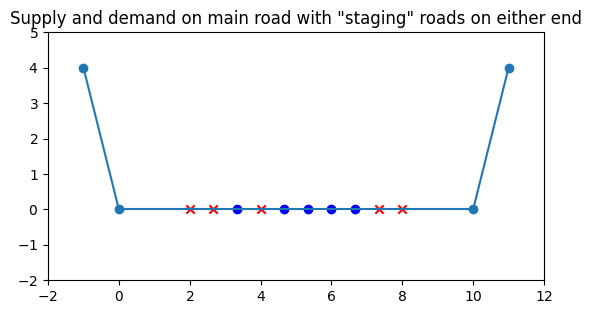

In [16]:
# Add "staging" roads on either end.
nodes = gpd.GeoDataFrame(
    {
        "point": [Point(-1, 4), Point(0, 0), Point(10, 0), Point(11, 4)]
    },
    # index=[...],
    geometry="point",
    crs=None,
)

topology = pd.DataFrame(
    {
        "u": [0, 1, 2,],
        "v": [1, 2, 3,],
    },
    index=["stage_left", "R", "stage_right"]
)

with_thru = GeoFramesRoads(topology, "u", "v").straight_lines_on(nodes)

ax = with_thru.edges_gdf.plot(ax=plt.gca())
with_thru.nodes_gdf.plot(ax=ax)
supply_gdf.plot(ax=ax, color="red", marker="x")
demand_gdf.plot(ax=ax, color="blue", marker="o")
plt.axis([-2, 12, -2, 5])
plt.title('Supply and demand on main road with "staging" roads on either end');

Now we can effect transshipment by placing additional supply or demand on the left staging road. The _net_ transshipment ($z$) will be the quantity of such supply minus such demand. Of course, we must place opposing demand (supply) on the right staging road to balance the matching instance.

Although represented as three roads now, the network is _metrically_ a single segment. Therefore sequential matching is still optimal. Let's see some examples below.

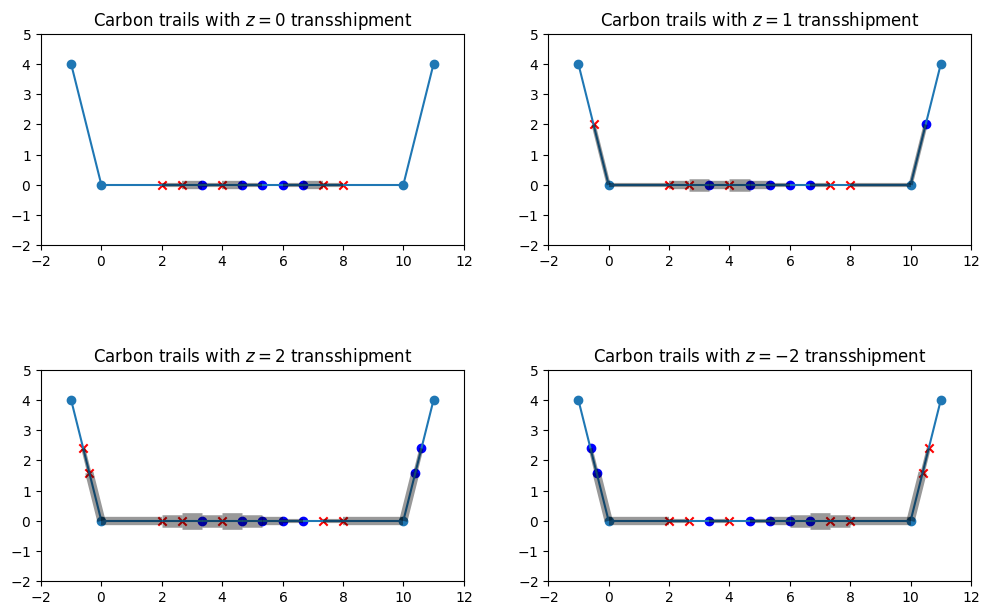

In [17]:
def space_between(n, a, b):
    return np.linspace(a, b, n + 2)[1:-1]

plt.figure(figsize=(12, 8))
for k, transshipment in enumerate([0, 1, 2, -2], 1):
    z = transshipment

    ll, lr = with_thru.length("stage_left"), with_thru.length("stage_right")

    left = [("stage_left", x) for x in space_between(abs(z), .2 * ll, .8 * ll)]
    right = [("stage_right", x) for x in space_between(abs(z), .2 * lr, .8 * lr)]

    if z >= 0:
        supply_ = [*left, *supply]
        demand_ = [*demand, *right]
    else:
        supply_ = [*supply, *right]
        demand_ = [*left, *demand]
    
    supply_gdf_, demand_gdf_ = points_to_gdf(supply_, with_thru.edges_gdf), points_to_gdf(demand_, with_thru.edges_gdf)

    pathnet, segments_gdf = create_path_network_with_surplus(supply_, demand_, with_thru, with_thru.edges_gdf)
    path_metric = RoadnetMetric(pathnet)

    weights = pd.Series(0, segments_gdf.index)
    for s, t in zip(supply_, demand_):
        path = path_metric.graph_shortest_path(PointNode(s), PointNode(t))
        segments = path[1::2]
        weights[segments] += 1

    plt.subplot(2, 2, k)
    ax = with_thru.edges_gdf.plot(ax=plt.gca())
    with_thru.nodes_gdf.plot(ax=ax)
    plot_w_linewidth_fixed(segments_gdf, ax=ax, linewidth=weights * WIDTH_PER_WEIGHT, alpha=.4, color="k")
    supply_gdf_.plot(ax=ax, color="red", marker="x")
    demand_gdf_.plot(ax=ax, color="blue", marker="o")
    plt.axis([-2, 12, -2, 5]);
    plt.title(f"Carbon trails with $z={transshipment}$ transshipment");
    ax.set_aspect("equal")

### Matching cost

As seen above, transshipment has a predictable effect on the "carbon footprint" of an optimal matching on the middle road. Specifically, given transshipment $z$, the total length of shortest path segments lying on road $r$ is now
$$\int_0^{|r|} | z + F_r(x) | \ {\rm d} x.$$

Note, similar observation can be found as early as ([Karp and Li, 1975](https://dl.acm.org/doi/abs/10.1016/0012-365X%2875%2990014-X)),
and can also be found in other works, e.g., ([Werman et. al., 1986](https://dl.acm.org/doi/abs/10.1016/0196-6774%2886%2990009-X)).

Importantly, it can be shown that this integral is a piece-wise linear and convex function of $z$, and has all its knots at integers. We can see those properties hold in the plot of the integral as a function of $z$ for our main road below.

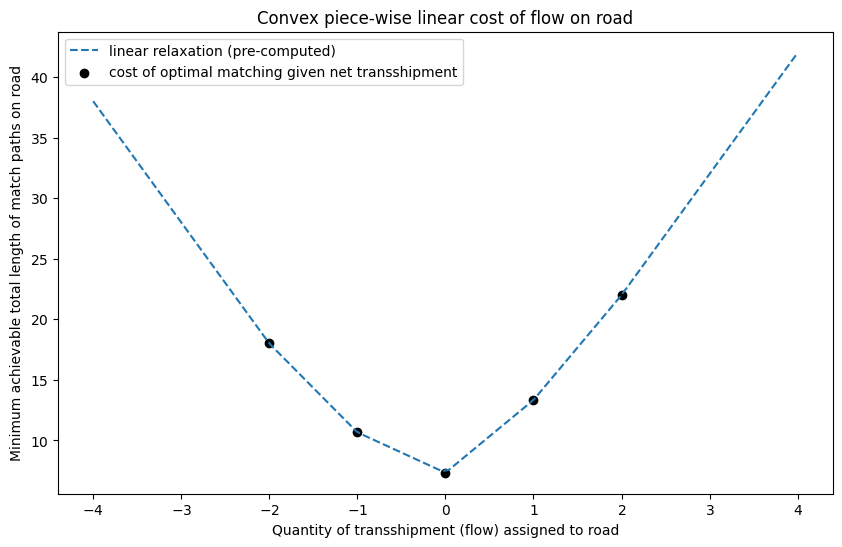

In [18]:
from setiptah.roadgeometry.matching import compute_roadnet_objective_fns
from shapely import LineString

road = segments_gdf[segments_gdf.road == "R"]

# The minimum cost of transshipment
def graph_cost(z):
    return (
        road.geometry.length * (road.F + z).abs()
    ).sum()

# Compute an efficiently queryable representation of the linear relaxation.
obj_fns = compute_roadnet_objective_fns(supply_, demand_, with_thru)
obj_fn = obj_fns["R"]

# Plot
vert_xs = list(obj_fn.lines.keys())[1::]
vert_ys = [graph_cost(z) for z in vert_xs]

plt.figure(figsize=(10, 6))
zs = np.linspace(min(vert_xs) - 2, max(vert_xs) + 2, 100)
plt.plot(zs, np.vectorize(obj_fn)(zs), "--", label="linear relaxation (pre-computed)")
plt.scatter(vert_xs, vert_ys, label="cost of optimal matching given net transshipment", color="k")
plt.xlabel("Quantity of transshipment (flow) assigned to road")
plt.ylabel("Minimum achievable total length of match paths on road")
plt.legend()
plt.title("Convex piece-wise linear cost of flow on road");

### Flow-based optimization

The last integral provides the basis for a reduction of matching to a [minimum cost flow problem](https://en.wikipedia.org/wiki/Minimum-cost_flow_problem).
The general minimum cost flow problem can be stated as:

Given a graph $(V, R)$,
a set of feasible "flows" $Z \subseteq R \to {\mathbb R}$, 
and cost function(s) $c: Z \times {\mathbb R} \to {\mathbb R}$,
minimize the total cost $\sum_{r \in R} c(r, z(r))$ over $z \in Z$.

For matching, the net transshipment $z(r)$ can be interpreted as network flow on road $r$, and the integral provides the cost $c(r, \cdot)$ for each road.
Optimizing total cost over feasible flows tells us how much transshipment to expect on each road!

### Algorithm summary

Given the intuition above, our algorithm is in three basic phases:
1. The first step of the algorithm pre-computes an efficiently $O(1)$-queryable representation of the integral for each road.
(Also -- although we have not discussed it -- an efficient representation of the feasible set $Z$.)
2. The algorithm then runs a very specific algorithm for flow optimization.
The key features of the chosen algorithm are that it supports convex objectives and has runtime which is very insensitive -- $O(\log n)$ -- to the total supply in the network.
3. Finally, given an optimal flow, it turns out we can efficiently construct a corresponding optimal matching.

We have taken a look at just the first step, but the paper (https://arxiv.org/abs/1311.4609) has more technical detail about the algorithm as a whole.

## Conclusion

Part I
- We have loaded a real world road network using PYROSM, and inspected it with GeoPandas.
- We have translated the network into a metric graph representation understood by the present framework.
- We briefly discussed the limitations of the standard way to obtain shortest path routing, which our library solves.
- We introduced the bipartite matching problem using a pizza delivery metaphor.
- Then, we demonstrated uniformly distributed random sampling over the road network to obtain a demo instance of supply and demand.
- We showed how to calculate and plot the "carbon footprint" (total distance traveled) of a naive matching solution.
- Next, we used our asymptotically efficient $O(n \log n)$ algorithm to compute an optimal matching in the sense of least total distance.
- We finished our "real-world" demo by plotting the carbon footprint of the optimal solution, showing a significant reduction.

Part II
- To demonstrate the key intution(s) behind our matching algorithm, first we discussed the characterization of matching on a single line segment -- the simplest kind of road network.
- Subsequently, we demonstrated the incremental effect of transshipment, or "flow", to that characterization, and discussed how matching on a network can be reduced to a network flow optimization.